   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

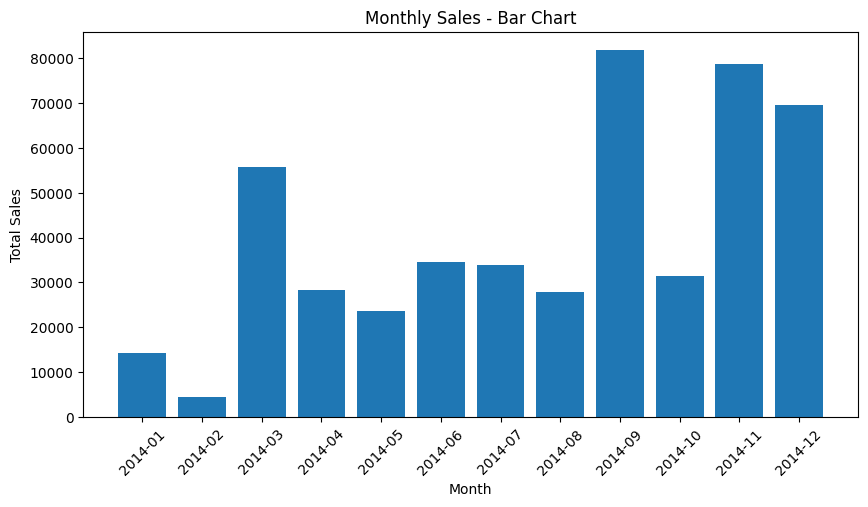

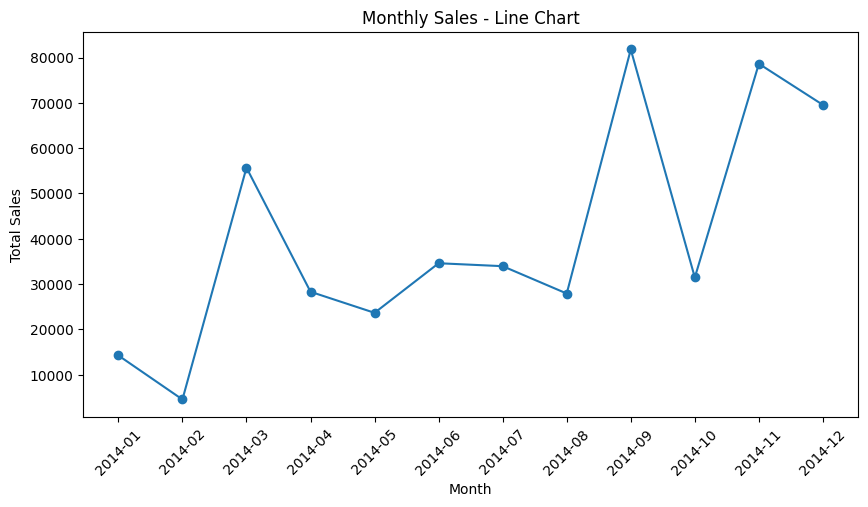

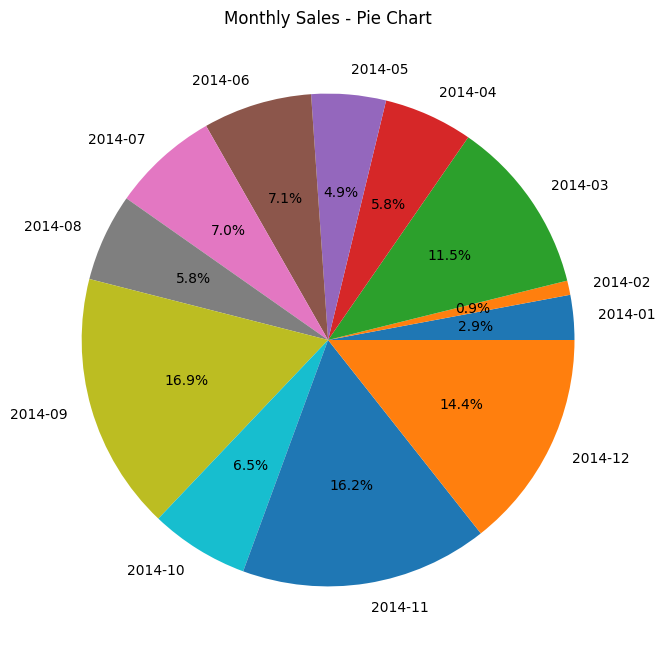

In [7]:
#task 1

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Sample-Superstore.csv", encoding="latin-1")

print(df.head())

df["Order Date"] = pd.to_datetime(df["Order Date"])

# Total sales by month
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

# Take first 12 months
monthly_sales = monthly_sales.head(12)

months = monthly_sales.index.astype(str)
sales = monthly_sales.values


# Bar Chart
plt.figure(figsize=(10, 5))
plt.bar(months, sales)
plt.title("Monthly Sales - Bar Chart")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


# Line Chart
plt.figure(figsize=(10, 5))
plt.plot(months, sales, marker="o")
plt.title("Monthly Sales - Line Chart")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


# Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(sales, labels=months, autopct="%1.1f%%")
plt.title("Monthly Sales - Pie Chart")
plt.show()

The bar chart is useful for comparing individual monthly sales, but with many months it becomes crowded.The line chart is the best ,it shows the trend best, while the pie chart hides the trend, because a pie chart focuses on proportions rather than chronological change.

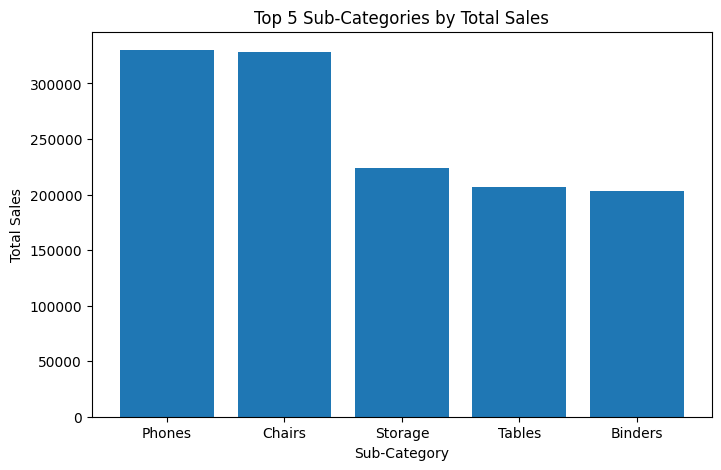

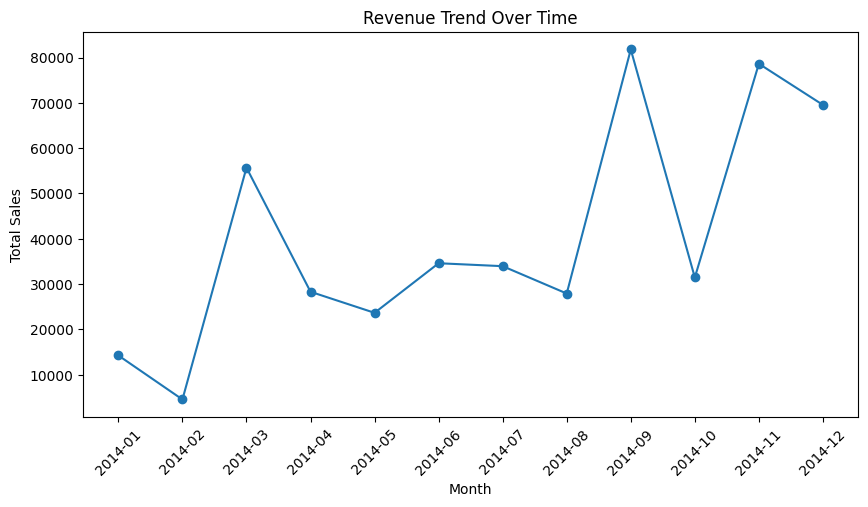

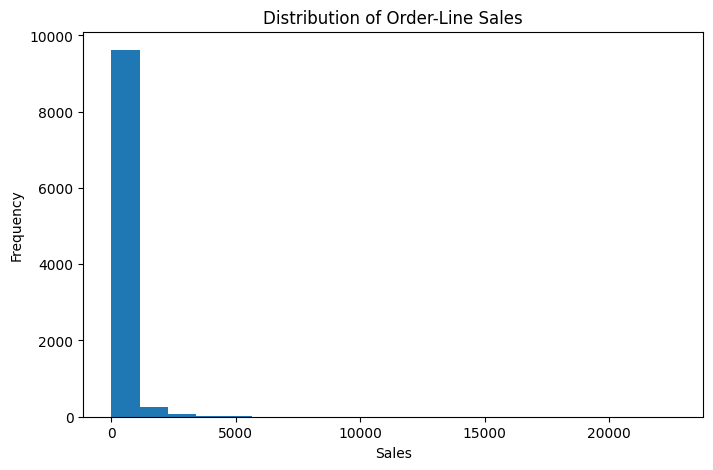

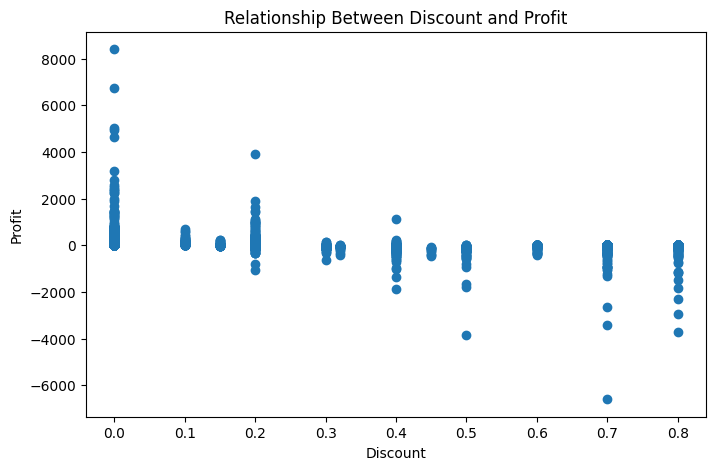

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Sample-Superstore.csv", encoding="latin-1")

# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])


# Top 5 sub-categories - Bar Chart

top5 = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8, 5))
plt.bar(top5.index, top5.values)

plt.title("Top 5 Sub-Categories by Total Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")

plt.show()


# Revenue Trend Over Time
# Same 12 months used in Task 1

monthly_sales = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Sales"].sum()

monthly_sales = monthly_sales.head(12)

months = monthly_sales.index.astype(str)
sales = monthly_sales.values

plt.figure(figsize=(10, 5))

plt.plot(months, sales, marker="o")

plt.title("Revenue Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()


# Distribution of Order-Line Sales Values

plt.figure(figsize=(8, 5))

plt.hist(df["Sales"], bins=20)

plt.title("Distribution of Order-Line Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()


# Discount vs Profit - Scatter Plot

plt.figure(figsize=(8, 5))

plt.scatter(df["Discount"], df["Profit"])

plt.title("Relationship Between Discount and Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

 Chart Type Explanation

1. Top 5 Sub-Categories -> Bar Chart
   Best for comparing sales between categories. A pie chart makes comparisons harder.

2. Revenue Trend->Line Chart
   Best for showing changes over time. A bar chart is less effective for showing trends.

3. Sales Distribution -> Histogram
   Best for showing the frequency and distribution of sales values. A bar chart is less suitable for continuous data.

4. Discount vs Profit -> Scatter Plot
   Best for showing the relationship between two numerical variables. A line chart could be misleading.

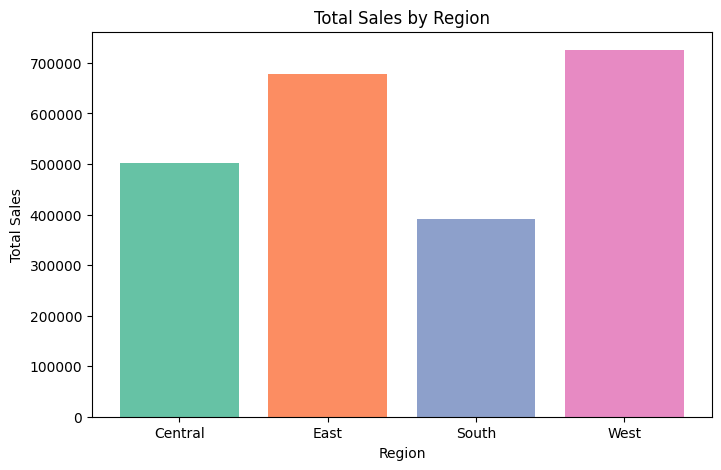

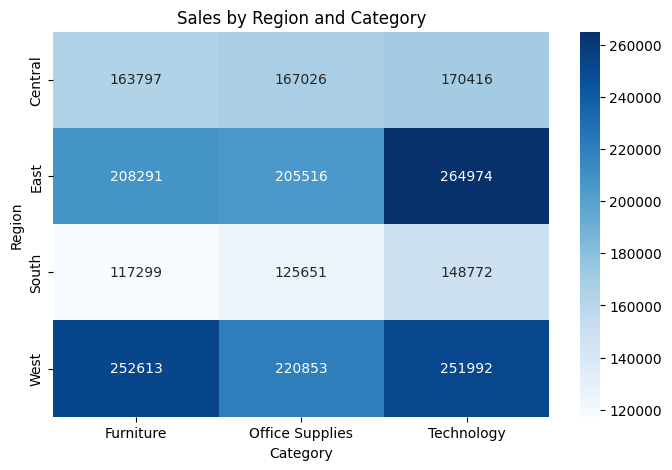

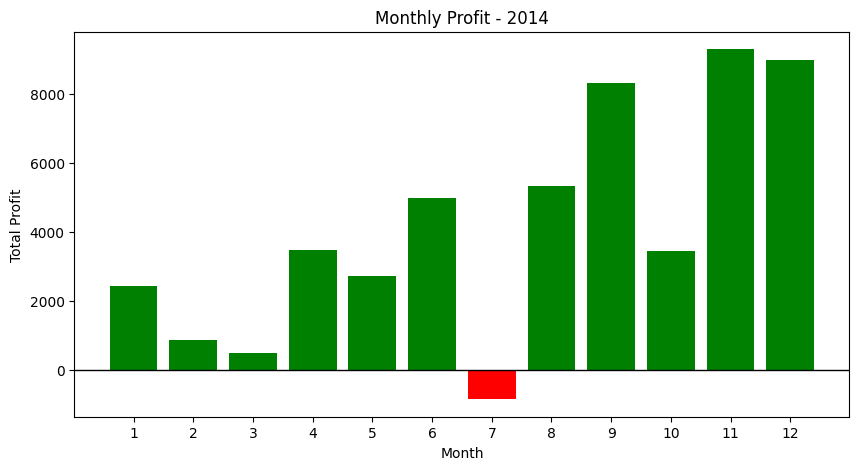

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Sample-Superstore.csv", encoding="latin-1")

df["Order Date"] = pd.to_datetime(df["Order Date"])

# (a) Total Sales by Region - Categorical Palette

region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8, 5))
plt.bar(
    region_sales.index,
    region_sales.values,
    color=sns.color_palette("Set2", len(region_sales))
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()


# (b) Sales by Region and Category - Sequential Heatmap

region_category = pd.pivot_table(
    df,
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    region_category,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Sales by Region and Category")
plt.xlabel("Category")
plt.ylabel("Region")
plt.show()

# (c) Monthly Profit - One Year

df["Year"] = df["Order Date"].dt.year


year = df["Year"].min()

monthly_profit = df[df["Year"] == year].groupby(
    df[df["Year"] == year]["Order Date"].dt.month
)["Profit"].sum()

months = range(1, 13)

plt.figure(figsize=(10, 5))

colors = ["red" if value < 0 else "green" for value in monthly_profit.values]

plt.bar(monthly_profit.index, monthly_profit.values, color=colors)

plt.axhline(0, color="black", linewidth=1)

plt.title(f"Monthly Profit - {year}")
plt.xlabel("Month")
plt.ylabel("Total Profit")

plt.xticks(months)

plt.show()

WCAG Contrast Ratio Results
Red vs White: 4.00:1 - FAIL
Green vs White: 5.14:1 - PASS
Blue vs White: 8.59:1 - PASS
White vs White: 1.00:1 - FAIL
Black vs White: 21.00:1 - PASS


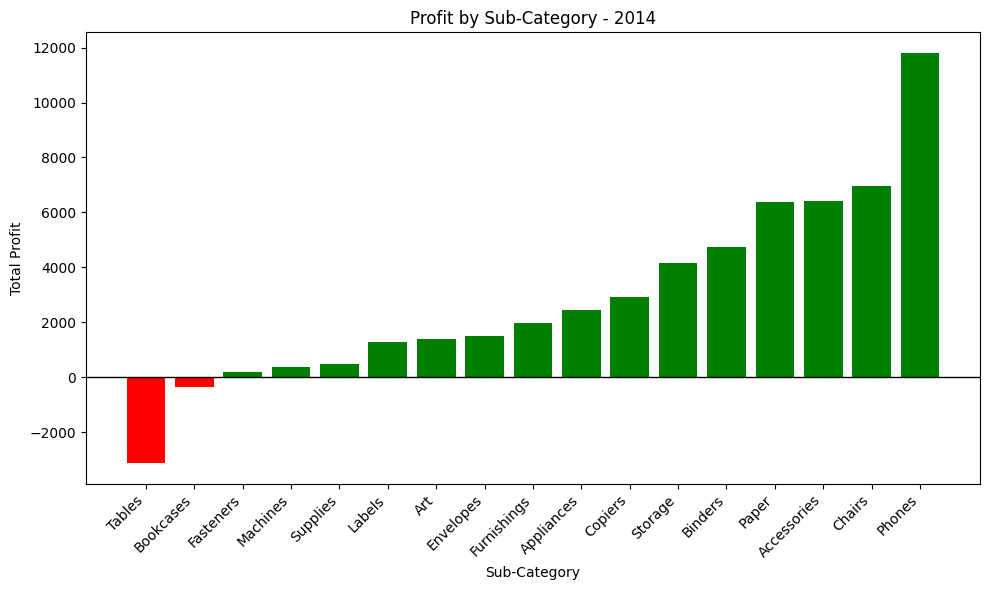

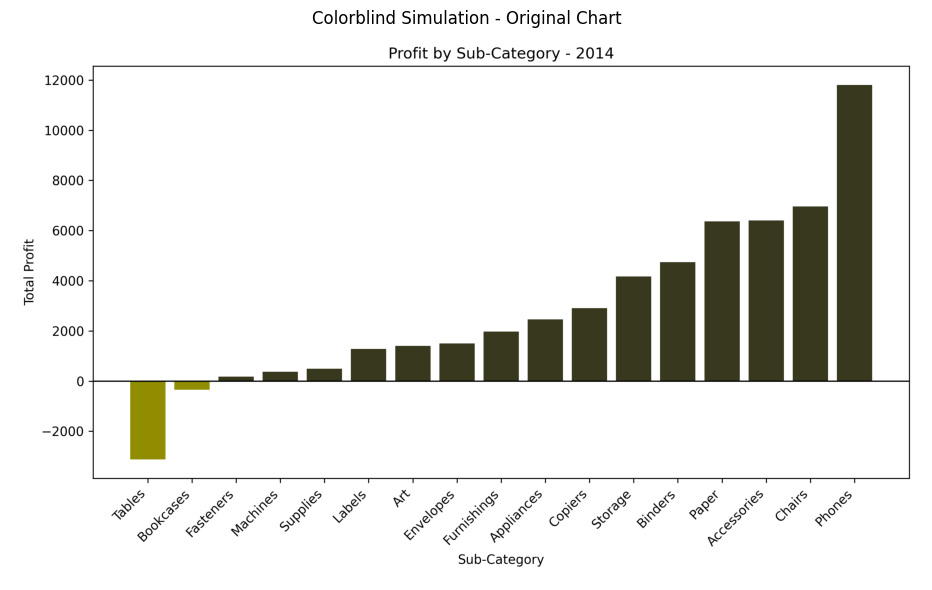

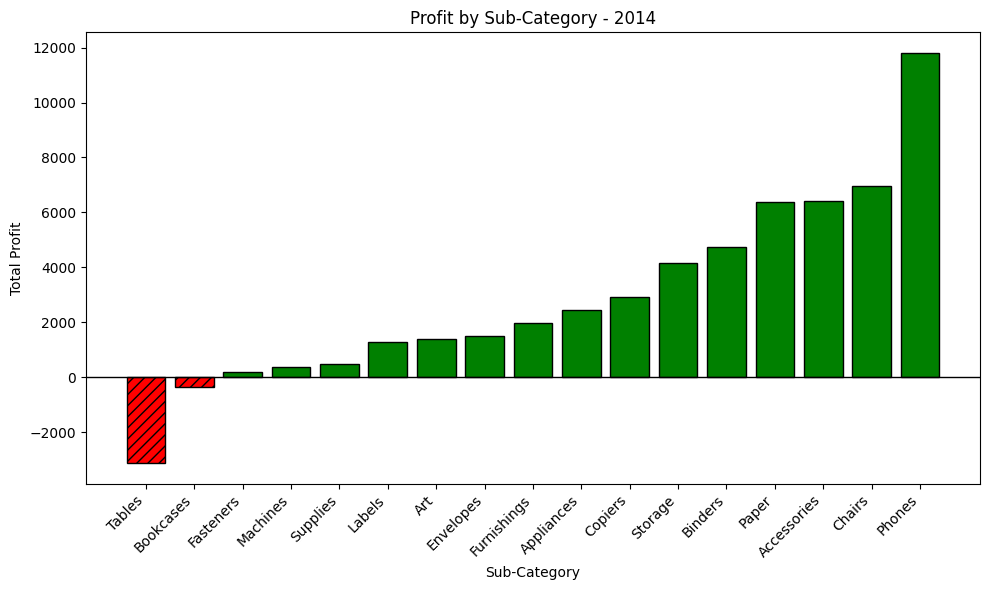

In [13]:
#task 4

import numpy as np

df = pd.read_csv("Sample-Superstore.csv", encoding="latin-1")
df["Order Date"] = pd.to_datetime(df["Order Date"])

# WCAG Contrast Ratio Function

def relative_luminance(rgb):
    rgb = np.array(rgb) / 255

    rgb = np.where(
        rgb <= 0.03928,
        rgb / 12.92,
        ((rgb + 0.055) / 1.055) ** 2.4
    )

    return (
        0.2126 * rgb[0]
        + 0.7152 * rgb[1]
        + 0.0722 * rgb[2]
    )


def contrast_ratio(color1, color2):
    l1 = relative_luminance(color1)
    l2 = relative_luminance(color2)

    lighter = max(l1, l2)
    darker = min(l1, l2)

    return (lighter + 0.05) / (darker + 0.05)


# Colors used in Task 3
task3_colors = {
    "Red": (255, 0, 0),
    "Green": (0, 128, 0),
    "Blue": (0, 0, 255),
    "White": (255, 255, 255),
    "Black": (0, 0, 0)
}

print("WCAG Contrast Ratio Results")

for name, color in task3_colors.items():
    ratio = contrast_ratio(color, (255, 255, 255))

    if ratio >= 4.5:
        status = "PASS"
    else:
        status = "FAIL"

    print(f"{name} vs White: {ratio:.2f}:1 - {status}")

# Profit by Sub-Category - One Year


df["Year"] = df["Order Date"].dt.year

year = df["Year"].min()

year_df = df[df["Year"] == year]

profit_subcategory = (
    year_df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values()
)


# Original Chart - Red and Green

plt.figure(figsize=(10, 6))

colors = [
    "red" if value < 0 else "green"
    for value in profit_subcategory.values
]

plt.bar(
    profit_subcategory.index,
    profit_subcategory.values,
    color=colors
)

plt.axhline(0, color="black", linewidth=1)

plt.title(f"Profit by Sub-Category - {year}")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("profit_original.png", dpi=300)
plt.show()



# Colorblind Simulation
# Protanopia Approximation

def simulate_protanopia(image):
    matrix = np.array([
        [0.567, 0.433, 0.000],
        [0.558, 0.442, 0.000],
        [0.000, 0.242, 0.758]
    ])

    image = image.astype(float) / 255
    simulated = image @ matrix.T

    return np.clip(simulated * 255, 0, 255).astype(np.uint8)


original = plt.imread("profit_original.png")

if original.shape[2] == 4:
    original_rgb = original[:, :, :3]
else:
    original_rgb = original

simulated = simulate_protanopia(
    (original_rgb * 255).astype(np.uint8)
)

plt.figure(figsize=(10, 6))
plt.imshow(simulated)
plt.axis("off")
plt.title("Colorblind Simulation - Original Chart")
plt.tight_layout()
plt.savefig("profit_colorblind_simulation.png", dpi=300)
plt.show()


# Fixed Chart - Color + Hatching


plt.figure(figsize=(10, 6))

for i, value in enumerate(profit_subcategory.values):

    if value < 0:
        color = "red"
        hatch = "///"
    else:
        color = "green"
        hatch = ""

    plt.bar(
        i,
        value,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.axhline(0, color="black", linewidth=1)

plt.title(f"Profit by Sub-Category - {year}")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")

plt.xticks(
    range(len(profit_subcategory)),
    profit_subcategory.index,
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.savefig("profit_fixed.png", dpi=300)
plt.show()




 Alt Text: Profit by sub-category for one year, with green bars showing gains and hatched red bars showing losses.

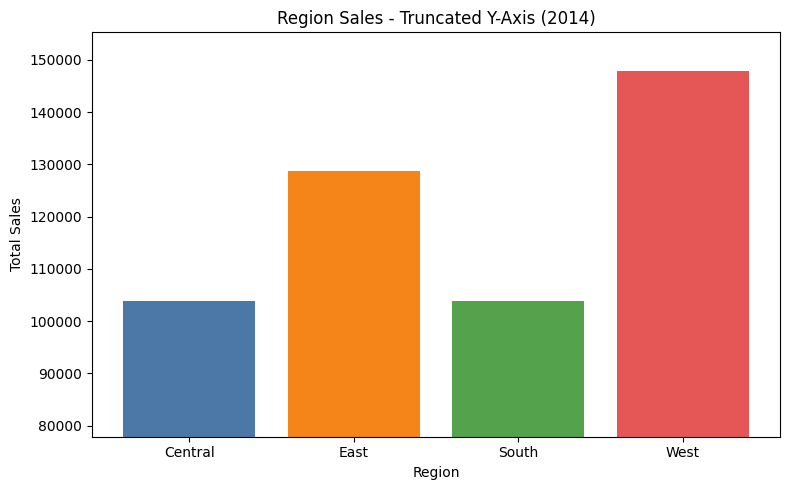

Caption: Truncated y-axis exaggerates differences between region sales.


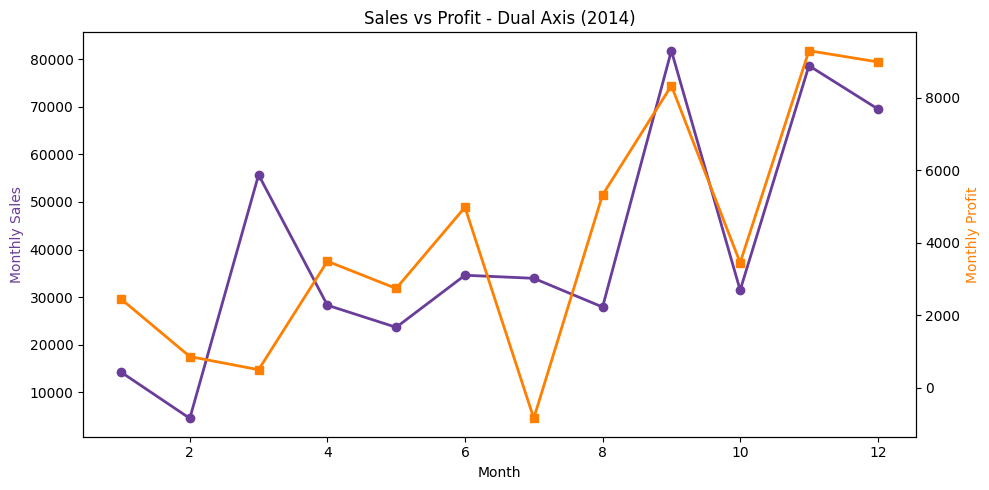

Caption: Dual axes can create a misleading impression of correlation between differently scaled measures.


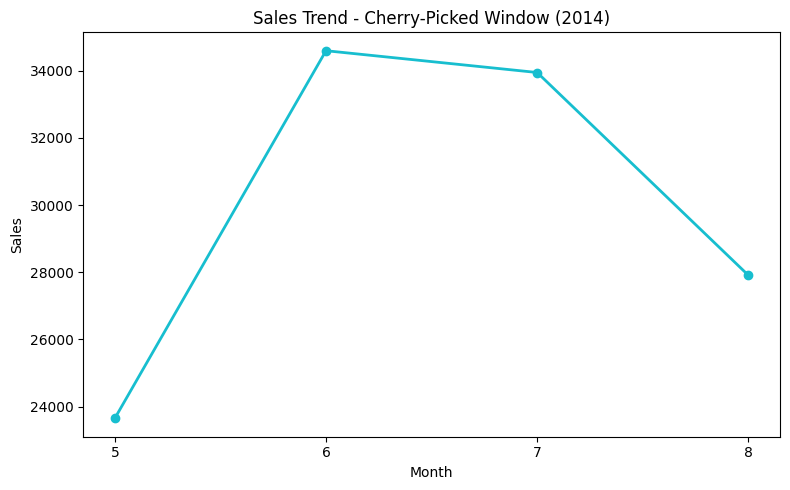

Caption: Cherry-picking May to August hides the surrounding yearly sales trend.


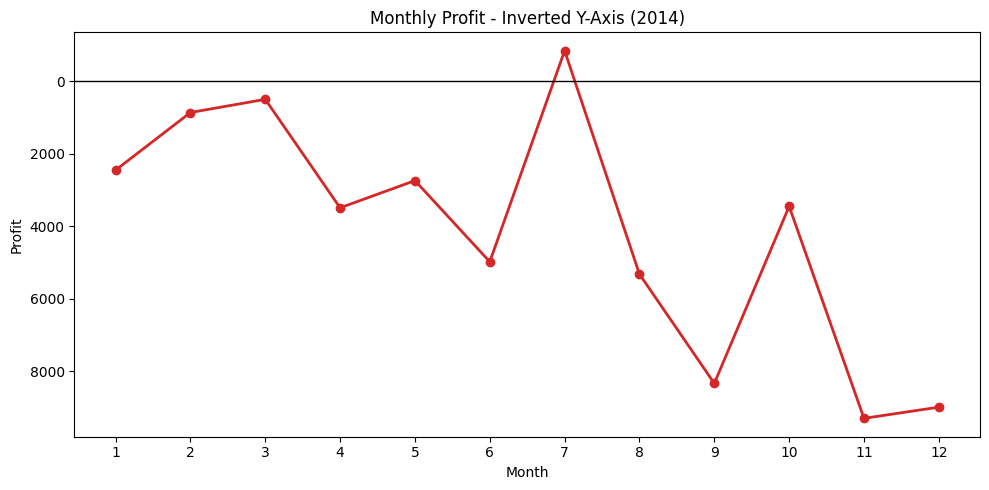

Caption: An inverted y-axis reverses the visual meaning of increases and decreases.


In [17]:
#task 5
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("Sample-Superstore.csv", encoding="latin-1")

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Year"] = df["Order Date"].dt.year

# Use only one year
year = df["Year"].min()
df_year = df[df["Year"] == year]

# Prepare data
region_sales = df_year.groupby("Region")["Sales"].sum()

monthly_sales = df_year.groupby(
    df_year["Order Date"].dt.month
)["Sales"].sum()

monthly_profit = df_year.groupby(
    df_year["Order Date"].dt.month
)["Profit"].sum()

months = range(1, 13)


# 1. Truncated Y-Axis

plt.figure(figsize=(8, 5))

plt.bar(
    region_sales.index,
    region_sales.values,
    color=["#4C78A8", "#F58518", "#54A24B", "#E45756"]
)

plt.ylim(region_sales.min() * 0.75, region_sales.max() * 1.05)

plt.title(f"Region Sales - Truncated Y-Axis ({year})")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

print("Caption: Truncated y-axis exaggerates differences between region sales.")


# 2. Dual-Axis Chart

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    months,
    monthly_sales.values,
    marker="o",
    color="#6A3D9A",
    linewidth=2
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Monthly Sales", color="#6A3D9A")

ax2 = ax1.twinx()

ax2.plot(
    months,
    monthly_profit.values,
    marker="s",
    color="#FF7F00",
    linewidth=2
)

ax2.set_ylabel("Monthly Profit", color="#FF7F00")

plt.title(f"Sales vs Profit - Dual Axis ({year})")
plt.tight_layout()
plt.show()

print("Caption: Dual axes can create a misleading impression of correlation between differently scaled measures.")


# 3. Cherry-Picked Date Window

cherry_sales = monthly_sales.loc[5:8]

plt.figure(figsize=(8, 5))

plt.plot(
    cherry_sales.index,
    cherry_sales.values,
    marker="o",
    color="#17BECF",
    linewidth=2
)

plt.title(f"Sales Trend - Cherry-Picked Window ({year})")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(cherry_sales.index)

plt.tight_layout()
plt.show()

print("Caption: Cherry-picking May to August hides the surrounding yearly sales trend.")


# 4. Inverted Y-Axis

plt.figure(figsize=(10, 5))

plt.plot(
    months,
    monthly_profit.values,
    marker="o",
    color="#D62728",
    linewidth=2
)

plt.axhline(0, color="black", linewidth=1)

plt.gca().invert_yaxis()

plt.title(f"Monthly Profit - Inverted Y-Axis ({year})")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(months)

plt.tight_layout()
plt.show()

print("Caption: An inverted y-axis reverses the visual meaning of increases and decreases.")




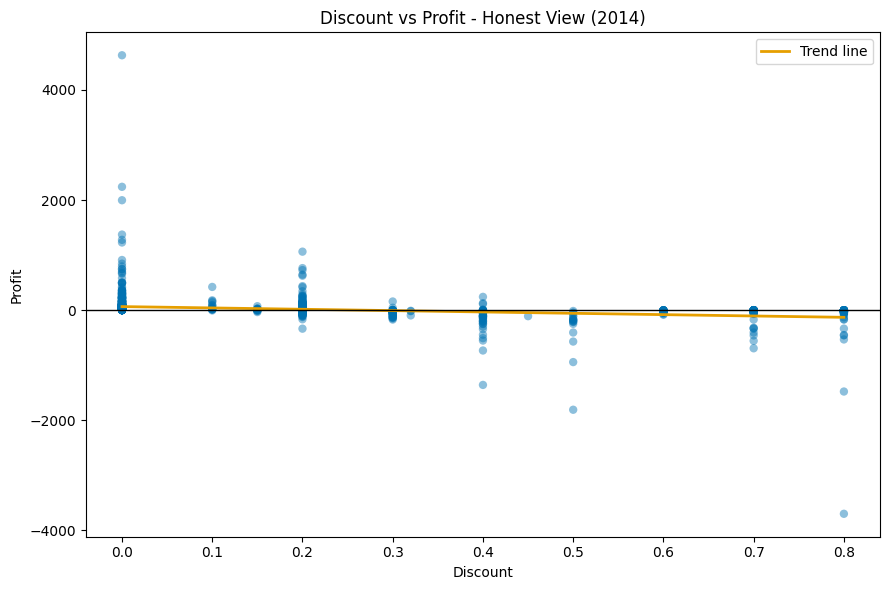

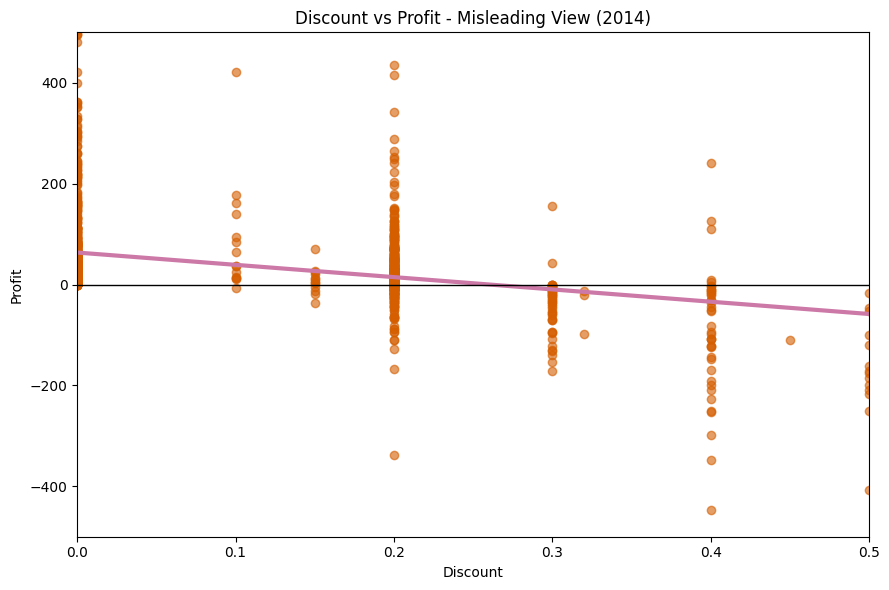

Accessibility Check
Blue and orange are used instead of red and green.
The zero-profit line is black for clear contrast.
Transparency reduces overlap between individual observations.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("Sample-Superstore.csv", encoding="latin-1")

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Year"] = df["Order Date"].dt.year

# Use only one year
year = df["Year"].min()
df_year = df[df["Year"] == year].copy()

# Remove missing values
data = df_year[["Discount", "Profit"]].dropna()

#honest chart
plt.figure(figsize=(9, 6))

plt.scatter(
    data["Discount"],
    data["Profit"],
    color="#0072B2",
    alpha=0.45,
    edgecolors="none"
)

# Trend line
x = data["Discount"].values
y = data["Profit"].values

slope, intercept = np.polyfit(x, y, 1)
trend = slope * x + intercept

order = np.argsort(x)

plt.plot(
    x[order],
    trend[order],
    color="#E69F00",
    linewidth=2,
    label="Trend line"
)

plt.axhline(0, color="black", linewidth=1)

plt.title(f"Discount vs Profit - Honest View ({year})")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.legend()

plt.tight_layout()
plt.savefig("honest_discount_profit.png", dpi=300)
plt.show()



# Deliberately Misleading Chart

plt.figure(figsize=(9, 6))

plt.scatter(
    data["Discount"],
    data["Profit"],
    color="#D55E00",
    alpha=0.6
)

plt.plot(
    x[order],
    trend[order],
    color="#CC79A7",
    linewidth=3
)

plt.axhline(0, color="black", linewidth=1)

#narrow y-axis to exaggerate
plt.xlim(0, 0.5)
plt.ylim(-500, 500)

plt.title(f"Discount vs Profit - Misleading View ({year})")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.savefig("misleading_discount_profit.png", dpi=300)
plt.show()


# Basic Accessibility Check


print("Accessibility Check")
print("Blue and orange are used instead of red and green.")
print("The zero-profit line is black for clear contrast.")
print("Transparency reduces overlap between individual observations.")


 Scatter plot showing the relationship between discount and profit for one year.